# Class 6: Introduction to Deep Learning

## Big Idea
Neural networks learn **nonlinear transformations** of features to make better predictions.

In [1]:
# Standard imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_circles, make_moons, fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.manifold import TSNE
import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.precision', 3)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)

# Random seed for reproducibility
prng = np.random.RandomState(20260304)

## Interactive Exploration

**Before we code, let's build intuition!**

Open [TensorFlow Playground](https://playground.tensorflow.org/) in your browser.

## Linear vs Nonlinear Models

### Motivation: Nonlinear Decision Boundaries

Let's start with a simple problem where linear models fail: **circular decision boundary**

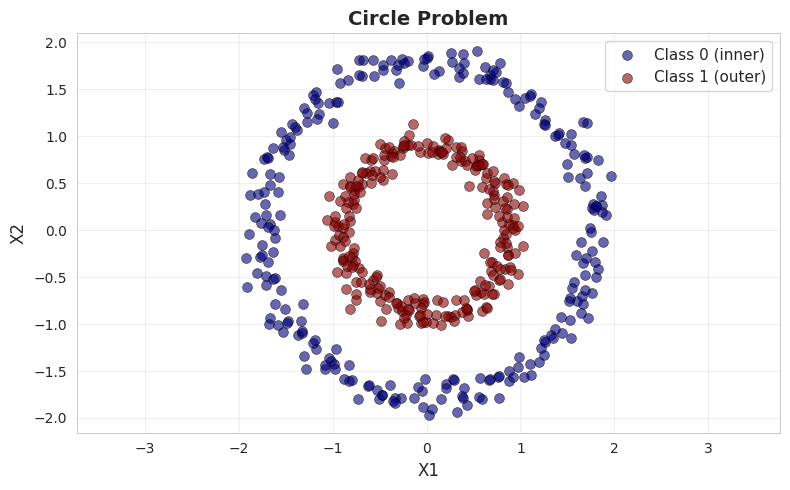

In [2]:
# Create circular data
X_circles, y_circles = make_circles(n_samples=500, noise=0.05, factor=0.5, random_state=prng)

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_circles)

# Visualize
plt.figure()
plt.scatter(X_scaled[y_circles == 0, 0], X_scaled[y_circles == 0, 1], 
            c='navy', label='Class 0 (inner)', alpha=0.6, s=50, edgecolors='k', linewidth=0.5)
plt.scatter(X_scaled[y_circles == 1, 0], X_scaled[y_circles == 1, 1], 
            c='darkred', label='Class 1 (outer)', alpha=0.6, s=50, edgecolors='k', linewidth=0.5)
plt.xlabel('X1', fontsize=12)
plt.ylabel('X2', fontsize=12)
plt.title('Circle Problem', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.axis('equal')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Train Neural Networks with Different Activation Functions

We'll train 3 models with 1 hidden layer containing 3 neurons:
- **Linear (identity)**: No nonlinearity
- **Sigmoid (logistic)**: Smooth nonlinear activation
- **ReLU**: Piecewise linear activation

In [3]:
# Train models with different activations
activations = ['identity', 'logistic', 'relu']
models = {}

for activation in activations:
    prng = np.random.RandomState(20260304)  # Reset for each model to ensure perfect reproducibility
    model = MLPClassifier(
        hidden_layer_sizes=(3,),
        activation=activation,
        solver='lbfgs',
        max_iter=2000,
        random_state=prng,
        alpha=0.01  # Standard regularization
    )
    model.fit(X_scaled, y_circles)
    models[activation] = model

### Visualize Decision Boundaries

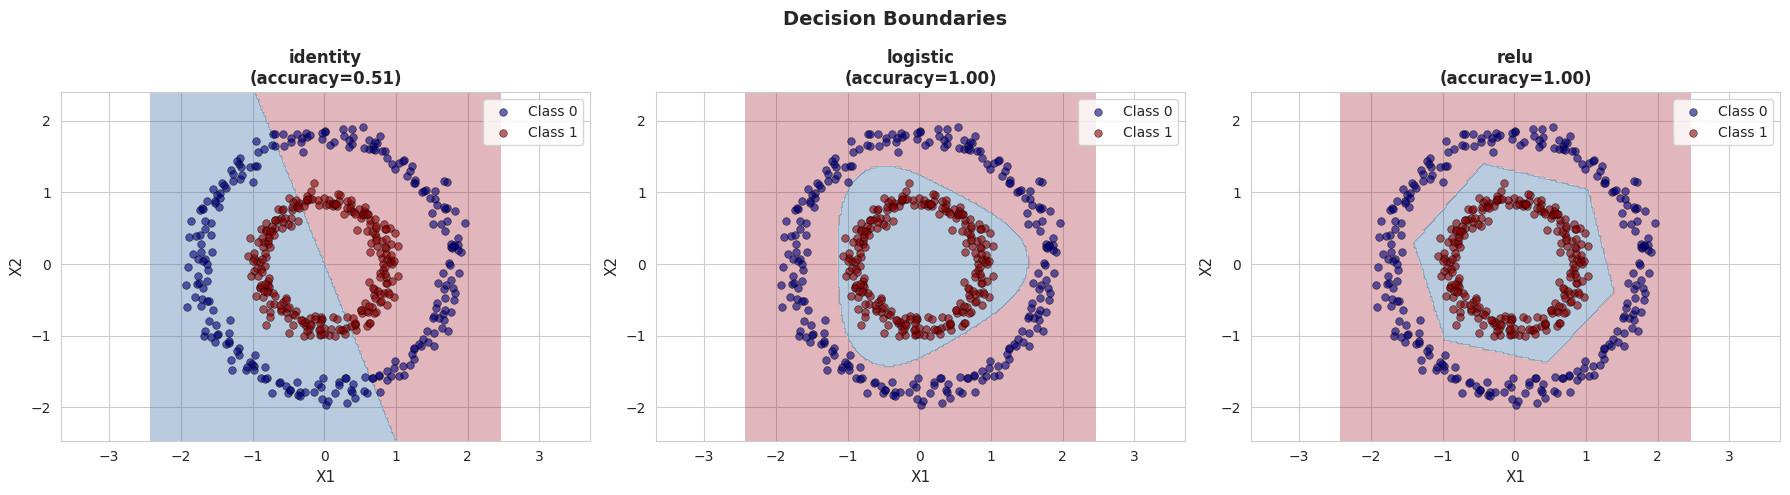

In [4]:
def plot_decision_boundary(X, y, model, title):
    """Plot decision boundary for a trained model"""
    h = 0.02  # step size
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    plt.contourf(xx, yy, Z, alpha=0.3, cmap='RdBu')
    plt.scatter(X[y == 0, 0], X[y == 0, 1], c='navy', label='Class 0', alpha=0.6, s=30, edgecolors='k', linewidth=0.5)
    plt.scatter(X[y == 1, 0], X[y == 1, 1], c='darkred', label='Class 1', alpha=0.6, s=30, edgecolors='k', linewidth=0.5)
    plt.xlabel('X1', fontsize=11)
    plt.ylabel('X2', fontsize=11)
    plt.title(title, fontsize=12, fontweight='bold')
    plt.legend(fontsize=10)
    plt.axis('equal')

# Plot all three
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for idx, (activation, model) in enumerate(models.items()):
    plt.sca(axes[idx])
    score = model.score(X_scaled, y_circles)
    plot_decision_boundary(X_scaled, y_circles, model, 
                          f'{activation}\n(accuracy={score:.2f})')
plt.suptitle('Decision Boundaries', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Deep Dive: How Hidden Neurons Transform the Data

Let's slice through the data at X2=0 and visualize what happens inside the hidden layer.

In [5]:
def visualize_hidden_layer_slice(model, activation_name, x1_range=(-2, 2), x2_fixed=0.0):
    """
    Visualize what happens in hidden layer along a 1D slice (x2=fixed)
    """
    # Create a slice of data points
    x1_vals = np.linspace(x1_range[0], x1_range[1], 200)
    x2_vals = np.full_like(x1_vals, x2_fixed)
    X_slice = np.column_stack([x1_vals, x2_vals])
    
    # Get weights and biases
    W1 = model.coefs_[0]  # Input to hidden: (2, 3)
    b1 = model.intercepts_[0]  # Hidden biases: (3,)
    W2 = model.coefs_[1]  # Hidden to output: (3, 1)
    b2 = model.intercepts_[1]  # Output biases: (1,)
    
    # Compute hidden layer pre-activation (z = X @ W1 + b1)
    z_hidden = X_slice @ W1 + b1  # (200, 3)
    
    # Apply activation function
    if activation_name == 'identity':
        h_hidden = z_hidden
        activation_fn = lambda x: x
    elif activation_name == 'logistic':
        h_hidden = 1 / (1 + np.exp(-z_hidden))
        activation_fn = lambda x: 1 / (1 + np.exp(-x))
    elif activation_name == 'relu':
        h_hidden = np.maximum(0, z_hidden)
        activation_fn = lambda x: np.maximum(0, x)
    
    # Compute output (before sigmoid)
    output_logit = h_hidden @ W2.flatten() + b2[0]
    output_prob = 1 / (1 + np.exp(-output_logit))
    
    return {
        'x1_vals': x1_vals,
        'z_hidden': z_hidden,
        'h_hidden': h_hidden,
        'output_logit': output_logit,
        'output_prob': output_prob,
        'activation_fn': activation_fn,
        'W1': W1,
        'b1': b1,
        'W2': W2,
        'b2': b2
    }


def plot_slice_location(X_scaled, y_circles, x2_fixed=0.0):
    """Plot where we're slicing the data"""
    fig, ax = plt.subplots(1, 1)
    ax.scatter(X_scaled[y_circles == 0, 0], X_scaled[y_circles == 0, 1], 
                c='navy', alpha=0.5, s=50, label='Class 0 (inner)', edgecolors='k', linewidth=0.5)
    ax.scatter(X_scaled[y_circles == 1, 0], X_scaled[y_circles == 1, 1], 
                c='darkred', alpha=0.5, s=50, label='Class 1 (outer)', edgecolors='k', linewidth=0.5)
    ax.axhline(y=x2_fixed, color='black', linestyle='--', linewidth=3, label=f'Slice at X2={x2_fixed}')
    ax.set_xlabel('X1', fontsize=12)
    ax.set_ylabel('X2', fontsize=12)
    ax.set_title(f'Circle Problem: 1D Slice at X2={x2_fixed}', fontsize=14, fontweight='bold')
    ax.legend(fontsize=11)
    ax.axis('equal')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


def plot_activation_comparison(models_data, activation_names, x2_fixed=0.0):
    """
    Create a comprehensive comparison chart with:
    - 3 rows (one per activation function)
    - 4 columns: activation function, pre-activation, post-activation+output, final prediction
    """
    fig, axes = plt.subplots(3, 4, figsize=(20, 12))
    
    colors = ['C0', 'C1', 'C2']  # Colors for the 3 neurons
    
    for row_idx, (activation_name, data) in enumerate(zip(activation_names, models_data)):
        x1_vals = data['x1_vals']
        z_hidden = data['z_hidden']
        h_hidden = data['h_hidden']
        output_logit = data['output_logit']
        output_prob = data['output_prob']
        activation_fn = data['activation_fn']
        
        # Column 1: Activation function shape
        ax = axes[row_idx, 0]
        z_range = np.linspace(-5, 5, 100)
        ax.plot(z_range, activation_fn(z_range), 'purple', linewidth=3)
        ax.set_xlabel('Input (z)', fontsize=11)
        ax.set_ylabel('Output h(z)', fontsize=11)
        ax.set_title(f'{activation_name.capitalize()}\nActivation Function', fontsize=12, fontweight='bold')
        ax.grid(True, alpha=0.3)
        ax.axhline(0, color='k', linewidth=0.5)
        ax.axvline(0, color='k', linewidth=0.5)
        
        # Column 2: Pre-activation values (z) for all 3 neurons
        ax = axes[row_idx, 1]
        for i in range(3):
            ax.plot(x1_vals, z_hidden[:, i], color=colors[i], linewidth=2, label=f'Neuron {i+1}')
        ax.axhline(0, color='k', linestyle='--', linewidth=1, alpha=0.5)
        ax.set_xlabel('X1 (at X2=0)', fontsize=11)
        ax.set_ylabel('Pre-activation (z)', fontsize=11)
        ax.set_title('Hidden Layer\nPre-Activation (z = w·x + b)', fontsize=12, fontweight='bold')
        ax.legend(fontsize=10)
        ax.grid(True, alpha=0.3)
        
        # Column 3: Post-activation values (h) + output logit
        ax = axes[row_idx, 2]
        for i in range(3):
            ax.plot(x1_vals, h_hidden[:, i], color=colors[i], linewidth=2, 
                   label=f'h{i+1}', alpha=0.7, linestyle='--')
        ax.plot(x1_vals, output_logit, 'purple', linewidth=3, label='Output (logit)')
        ax.axhline(0, color='k', linestyle='--', linewidth=1, alpha=0.5)
        ax.set_xlabel('X1 (at X2=0)', fontsize=11)
        ax.set_ylabel('Value', fontsize=11)
        ax.set_title(f'After {activation_name.capitalize()}\n+ Output (before sigmoid)', fontsize=12, fontweight='bold')
        ax.legend(fontsize=10, loc='best')
        ax.grid(True, alpha=0.3)
        
        # Column 4: Final prediction (after sigmoid)
        ax = axes[row_idx, 3]
        ax.plot(x1_vals, output_prob, 'purple', linewidth=3, label='P(Class 1)')
        ax.axhline(0.5, color='k', linestyle='--', linewidth=1.5, alpha=0.7, label='Decision boundary')
        ax.fill_between(x1_vals, 0, output_prob, where=(output_prob < 0.5), 
                          alpha=0.3, color='blue', label='Predict Class 0')
        ax.fill_between(x1_vals, output_prob, 1, where=(output_prob >= 0.5), 
                          alpha=0.3, color='red', label='Predict Class 1')
        ax.set_xlabel('X1 (at X2=0)', fontsize=11)
        ax.set_ylabel('Probability', fontsize=11)
        ax.set_title('Final Prediction\n(after sigmoid)', fontsize=12, fontweight='bold')
        ax.set_ylim(0, 1)
        ax.legend(fontsize=9, loc='best')
        ax.grid(True, alpha=0.3)
    
    plt.suptitle(f'Activation Function Comparison: Hidden Layer Visualization (X2={x2_fixed})', 
                 fontsize=16, fontweight='bold', y=0.995)
    plt.tight_layout()
    plt.show()

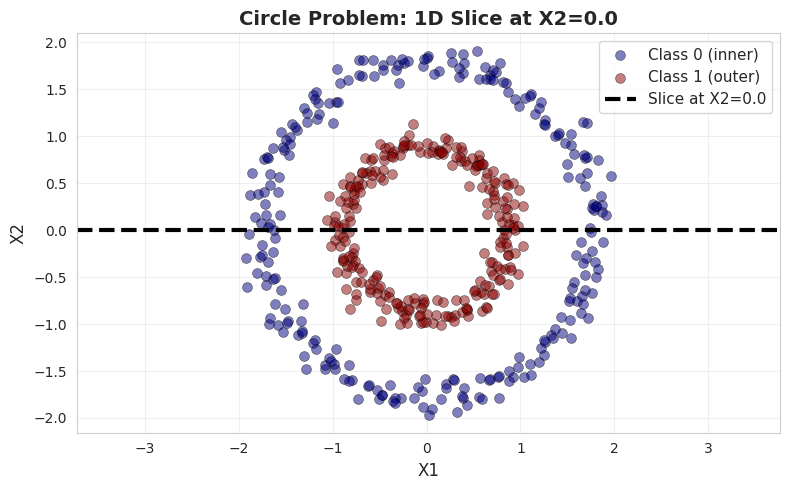

In [6]:
# Show where we're slicing the data
plot_slice_location(X_scaled, y_circles, x2_fixed=0.0)

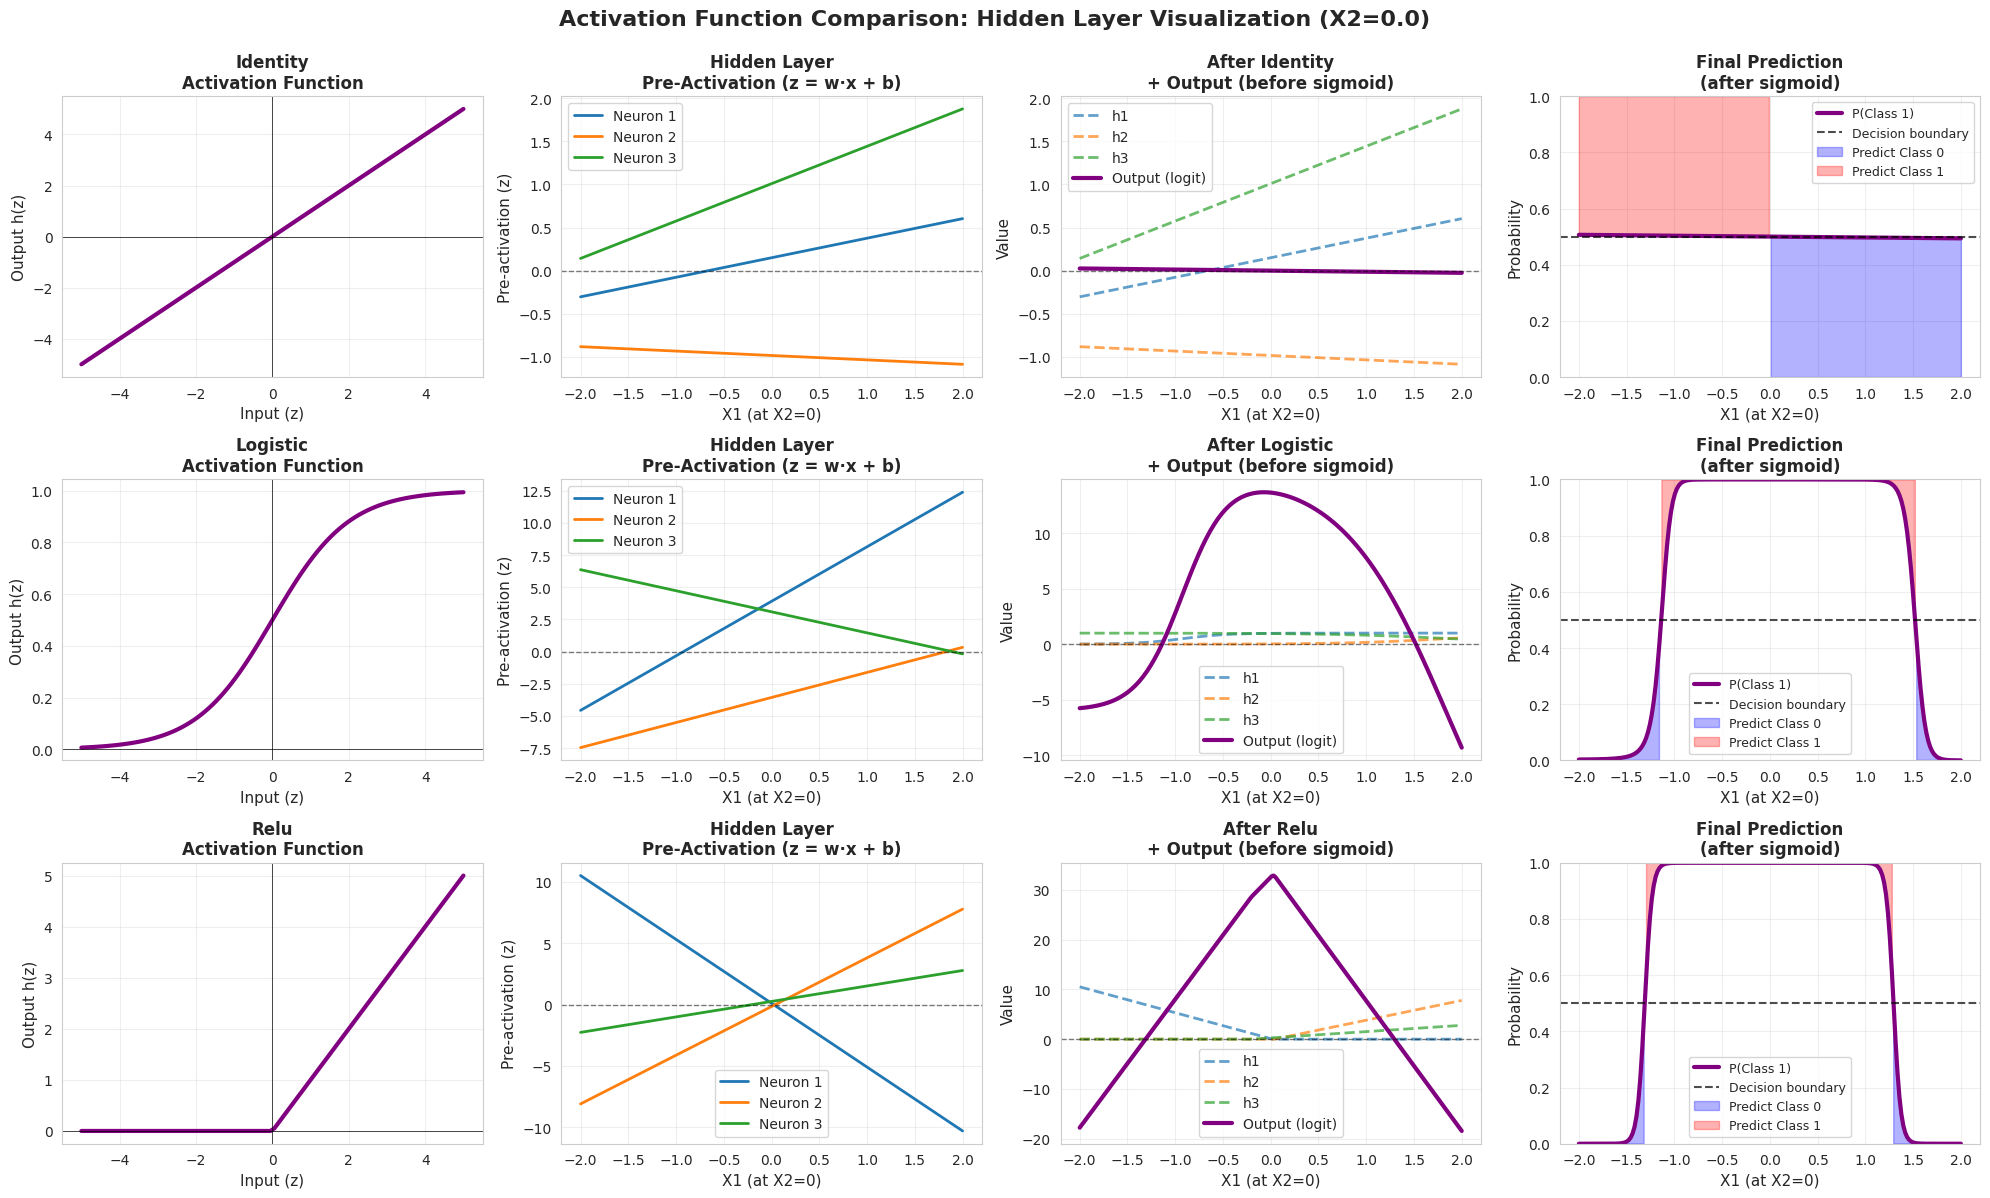

In [7]:
# Compute slice data for all activation functions
activation_names = ['identity', 'logistic', 'relu']
models_data = []

for activation_name in activation_names:
    if activation_name in models:
        data = visualize_hidden_layer_slice(models[activation_name], activation_name, x2_fixed=0.0)
        models_data.append(data)

# Plot comprehensive comparison
plot_activation_comparison(models_data, activation_names, x2_fixed=0.0)

## Deep Learning in Action — MNIST

### Load and Prepare MNIST

MNIST dataset:
- 70,000 handwritten digit images (0-9)
- 28×28 pixels = 784 features per image
- Grayscale values from 0 (white) to 255 (black)
- work with a sample of 5000 images for faster trainings

In [96]:
print("Loading MNIST dataset...")
mnist = fetch_openml('mnist_784', version=1, parser='auto', as_frame=False)
X_mnist = mnist.data
y_mnist = mnist.target.astype(int)

prng = np.random.RandomState(20260304)

X_train, X_test, y_train, y_test = train_test_split(
    X_mnist[:6000], y_mnist[:6000], test_size=1000, random_state=prng
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")

Loading MNIST dataset...
Training set: (5000, 784)
Test set: (1000, 784)


Let's use our `ResultCollector` adapted from the bike share demand notebook to track classification experiments.

In [103]:
class ResultCollector:
    def __init__(self):
        self.results = {}

    def add_model(self, name, train_acc, test_acc):
        """Add or update a model's results."""
        self.results[name] = {
            'Train Accuracy': train_acc,
            'Test Accuracy': test_acc,
            'Gap': train_acc - test_acc
        }
        return self.get_table()

    def get_table(self, style=True):
        """Get the results table with optional styling."""
        df = pd.DataFrame(self.results).T
        baseline_acc = df['Test Accuracy'].iloc[0]
        df['Improvement over Baseline'] = df['Test Accuracy'].apply(
            lambda x: f"{round(100 * (x - baseline_acc) / baseline_acc, 2)}%"
        )
        if style:
            return df.style.format("{:.4f}", subset=['Train Accuracy', 'Test Accuracy', 'Gap']) \
                .background_gradient(cmap='RdYlGn', subset=['Test Accuracy'], axis=None)
        return df

results = ResultCollector()

### Baseline: Logistic Regression

In [104]:
log_reg = LogisticRegression(max_iter=100, random_state=prng)
log_reg.fit(X_train_scaled, y_train)

results.add_model(
    'Logistic Regression',
    log_reg.score(X_train_scaled, y_train),
    log_reg.score(X_test_scaled, y_test)
)

,Train Accuracy,Test Accuracy,Gap,Improvement over Baseline
Logistic Regression,1.0000,0.9060,0.0940,0.0%


### First neural network: start small

In [105]:
mlp_small = MLPClassifier(
    hidden_layer_sizes=(32,),
    max_iter=20,
    alpha=0,
    random_state=prng,
)
mlp_small.fit(X_train_scaled, y_train)

results.add_model(
    'Small MLP (32 neurons)',
    mlp_small.score(X_train_scaled, y_train),
    mlp_small.score(X_test_scaled, y_test)
)

results.get_table()

,Train Accuracy,Test Accuracy,Gap,Improvement over Baseline
Logistic Regression,1.0000,0.9060,0.0940,0.0%
Small MLP (32 neurons),0.9916,0.9390,0.0526,3.64%


### Experiment 1: Architecture — Depth vs Width

We compare architectures along two dimensions:
- **Width**: number of neurons per layer (narrow vs wide)
- **Depth**: number of hidden layers (shallow vs deep)

All models use `max_iter=20` and no explicit regularization (`alpha=0`) so we can isolate the effect of architecture. With only 20 epochs, smaller networks may not fully converge: showing their limited capacity.

In [106]:
architectures = {
    'Shallow-Wide (256,)':          (256,),
    'Deep-Narrow (32,32,32)':       (32, 32, 32),
    'Deep-Wide (256,256,256)':      (256, 256, 256),
    'Medium (128,64)':              (128, 64),
}

arch_models = {}
for name, layers in architectures.items():
    n_params = 784 * layers[0] + layers[0]  # input to first hidden
    for i in range(1, len(layers)):
        n_params += layers[i-1] * layers[i] + layers[i]
    n_params += layers[-1] * 10 + 10  # last hidden to output
    print(f"{name:30s} | arch={str(layers):20s} | ~{n_params:,} parameters")

    mlp = MLPClassifier(
        hidden_layer_sizes=layers,
        max_iter=20,
        alpha=0,
        random_state=prng,
    )
    mlp.fit(X_train_scaled, y_train)
    arch_models[name] = mlp

    results.add_model(
        name,
        mlp.score(X_train_scaled, y_train),
        mlp.score(X_test_scaled, y_test)
    )

results.get_table()

Shallow-Wide (256,)            | arch=(256,)               | ~203,530 parameters
Deep-Narrow (32,32,32)         | arch=(32, 32, 32)         | ~27,562 parameters
Deep-Wide (256,256,256)        | arch=(256, 256, 256)      | ~335,114 parameters
Medium (128,64)                | arch=(128, 64)            | ~109,386 parameters


,Train Accuracy,Test Accuracy,Gap,Improvement over Baseline
Logistic Regression,1.0000,0.9060,0.0940,0.0%
Small MLP (32 neurons),0.9916,0.9390,0.0526,3.64%
"Shallow-Wide (256,)",1.0000,0.9550,0.0450,5.41%
"Deep-Narrow (32,32,32)",0.9984,0.9410,0.0574,3.86%
"Deep-Wide (256,256,256)",1.0000,0.9530,0.0470,5.19%
"Medium (128,64)",1.0000,0.9590,0.0410,5.85%


### Experiment 2: Regularization

Now we train the **Deep-Wide (256,256,256)** architecture for longer (`max_iter=100`) so it has time to memorize the training data. Then we apply regularization to fight overfitting.

#### 2a: L2 Weight Decay (alpha parameter)

The `alpha` parameter in `MLPClassifier` controls L2 regularization — it penalizes large weights:

$$\text{Loss}_{\text{total}} = \text{Loss}_{\text{data}} + \alpha \sum_i w_i^2$$

In [107]:
alphas = [0, 1e-4, 1e-3, 1e-2, 1e-1]
l2_models = {}

for alpha in alphas:
    name = f'Deep-Wide alpha={alpha}'
    mlp = MLPClassifier(
        hidden_layer_sizes=(256, 256, 256),
        max_iter=100,
        alpha=alpha,
        random_state=prng,
    )
    mlp.fit(X_train_scaled, y_train)
    l2_models[name] = mlp

    results.add_model(
        name,
        mlp.score(X_train_scaled, y_train),
        mlp.score(X_test_scaled, y_test)
    )

results.get_table()

,Train Accuracy,Test Accuracy,Gap,Improvement over Baseline
Logistic Regression,1.0000,0.9060,0.0940,0.0%
Small MLP (32 neurons),0.9916,0.9390,0.0526,3.64%
"Shallow-Wide (256,)",1.0000,0.9550,0.0450,5.41%
"Deep-Narrow (32,32,32)",0.9984,0.9410,0.0574,3.86%
"Deep-Wide (256,256,256)",1.0000,0.9530,0.0470,5.19%
"Medium (128,64)",1.0000,0.9590,0.0410,5.85%
Deep-Wide alpha=0,1.0000,0.9570,0.0430,5.63%
Deep-Wide alpha=0.0001,1.0000,0.9590,0.0410,5.85%
Deep-Wide alpha=0.001,1.0000,0.9580,0.0420,5.74%
Deep-Wide alpha=0.01,1.0000,0.9640,0.0360,6.4%


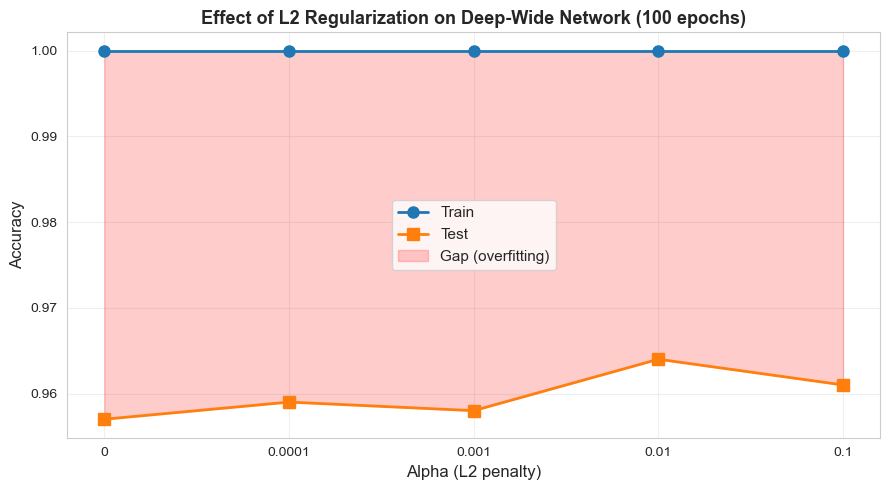

In [108]:
# Visualize the effect of alpha
df_l2 = pd.DataFrame({
    'alpha': alphas,
    'Train': [l2_models[f'Deep-Wide alpha={a}'].score(X_train_scaled, y_train) for a in alphas],
    'Test':  [l2_models[f'Deep-Wide alpha={a}'].score(X_test_scaled, y_test) for a in alphas],
})

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(range(len(alphas)), df_l2['Train'], 'o-', label='Train', linewidth=2, markersize=8)
ax.plot(range(len(alphas)), df_l2['Test'], 's-', label='Test', linewidth=2, markersize=8)
ax.fill_between(range(len(alphas)), df_l2['Train'], df_l2['Test'],
                alpha=0.2, color='red', label='Gap (overfitting)')
ax.set_xticks(range(len(alphas)))
ax.set_xticklabels([str(a) for a in alphas])
ax.set_xlabel('Alpha (L2 penalty)', fontsize=12)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('Effect of L2 Regularization on Deep-Wide Network (100 epochs)',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()

#### 2b: Early Stopping

Stop training when validation performance stops improving — even if training loss is still decreasing. This prevents the model from memorizing training data.

In [109]:
mlp_early = MLPClassifier(
    hidden_layer_sizes=(256, 256, 256),
    max_iter=300,
    alpha=0,
    early_stopping=True,
    validation_fraction=0.2,
    n_iter_no_change=10,
    random_state=prng,
)
mlp_early.fit(X_train_scaled, y_train)

print(f"Stopped at iteration {mlp_early.n_iter_} (out of max 300)")

results.add_model(
    'Deep-Wide + Early Stopping',
    mlp_early.score(X_train_scaled, y_train),
    mlp_early.score(X_test_scaled, y_test)
)
results.get_table()

Stopped at iteration 20 (out of max 300)


,Train Accuracy,Test Accuracy,Gap,Improvement over Baseline
Logistic Regression,1.0000,0.9060,0.0940,0.0%
Small MLP (32 neurons),0.9916,0.9390,0.0526,3.64%
"Shallow-Wide (256,)",1.0000,0.9550,0.0450,5.41%
"Deep-Narrow (32,32,32)",0.9984,0.9410,0.0574,3.86%
"Deep-Wide (256,256,256)",1.0000,0.9530,0.0470,5.19%
"Medium (128,64)",1.0000,0.9590,0.0410,5.85%
Deep-Wide alpha=0,1.0000,0.9570,0.0430,5.63%
Deep-Wide alpha=0.0001,1.0000,0.9590,0.0410,5.85%
Deep-Wide alpha=0.001,1.0000,0.9580,0.0420,5.74%
Deep-Wide alpha=0.01,1.0000,0.9640,0.0360,6.4%


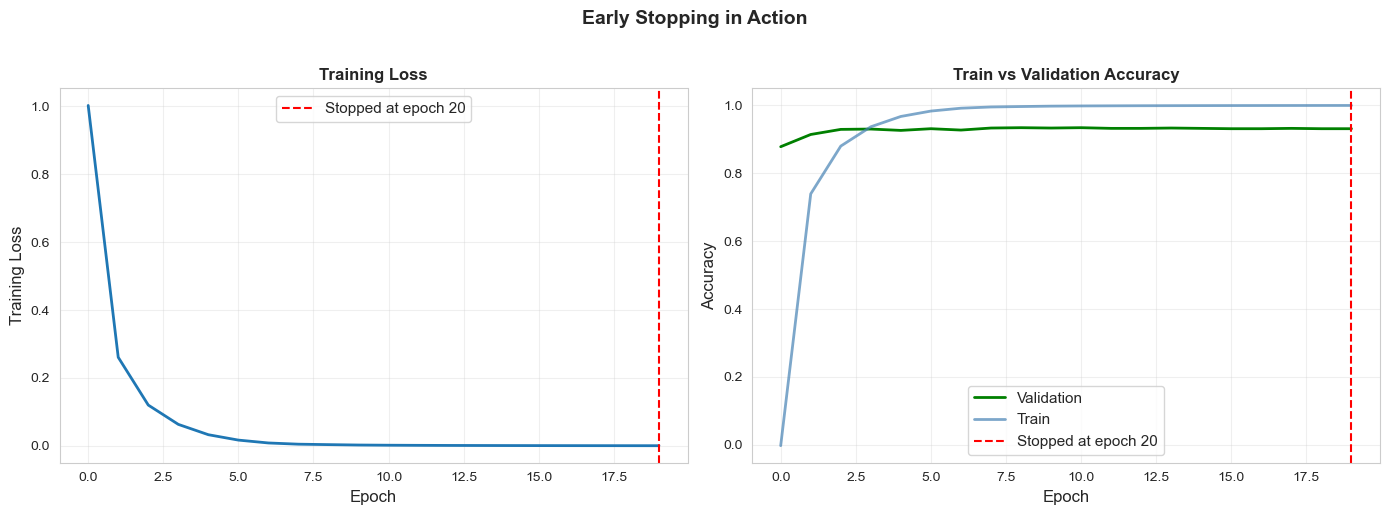

In [111]:
# Training vs validation curve for early stopping
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(mlp_early.loss_curve_, linewidth=2)
axes[0].axvline(mlp_early.n_iter_ - 1, color='red', linestyle='--',
                label=f'Stopped at epoch {mlp_early.n_iter_}')
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Training Loss', fontsize=12)
axes[0].set_title('Training Loss', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Compute train accuracy per epoch (approximate from training subset used for validation)
train_acc_curve = [1 - loss for loss in mlp_early.loss_curve_]  # Approximation
axes[1].plot(mlp_early.validation_scores_, linewidth=2, color='green', label='Validation')
axes[1].plot(train_acc_curve, linewidth=2, color='steelblue', label='Train', alpha=0.7)
axes[1].axvline(mlp_early.n_iter_ - 1, color='red', linestyle='--',
                label=f'Stopped at epoch {mlp_early.n_iter_}')
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Accuracy', fontsize=12)
axes[1].set_title('Train vs Validation Accuracy', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.suptitle('Early Stopping in Action', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()

### 2c: Combining L2 + Early Stopping

In [112]:
mlp_combined = MLPClassifier(
    hidden_layer_sizes=(256, 256, 256),
    max_iter=300,
    alpha=1e-3,
    early_stopping=True,
    validation_fraction=0.2,
    n_iter_no_change=10,
    random_state=prng,
)
mlp_combined.fit(X_train_scaled, y_train)

print(f"Stopped at iteration {mlp_combined.n_iter_}")

results.add_model(
    'Deep-Wide + L2 + Early Stop',
    mlp_combined.score(X_train_scaled, y_train),
    mlp_combined.score(X_test_scaled, y_test)
)
results.get_table()

Stopped at iteration 19


,Train Accuracy,Test Accuracy,Gap,Improvement over Baseline
Logistic Regression,1.0000,0.9060,0.0940,0.0%
Small MLP (32 neurons),0.9916,0.9390,0.0526,3.64%
"Shallow-Wide (256,)",1.0000,0.9550,0.0450,5.41%
"Deep-Narrow (32,32,32)",0.9984,0.9410,0.0574,3.86%
"Deep-Wide (256,256,256)",1.0000,0.9530,0.0470,5.19%
"Medium (128,64)",1.0000,0.9590,0.0410,5.85%
Deep-Wide alpha=0,1.0000,0.9570,0.0430,5.63%
Deep-Wide alpha=0.0001,1.0000,0.9590,0.0410,5.85%
Deep-Wide alpha=0.001,1.0000,0.9580,0.0420,5.74%
Deep-Wide alpha=0.01,1.0000,0.9640,0.0360,6.4%


### 2d: Dropout

Dropout randomly "drops" (disables) a fraction of neurons during each training iteration, forcing the network to learn redundant representations.

Sklearn's MLP implementation does not support dropout, so we will get back to it on week 5 when we'll introduce TensorFlow.

---

## Key Takeaways

### 1. Neural networks = learned nonlinear transformations
- Each hidden layer creates new features
- Depth enables hierarchical learning: simple → complex patterns
- **3B1B showed this beautifully**: pixels → edges → shapes → digits

### 2. Training = optimization via gradient descent
- Cost function measures prediction error
- Backpropagation computes gradients efficiently (sklearn does this!)
- Like K-means (Class 3): iterative, needs good initialization

### 3. Architecture matters
- More neurons/layers = more capacity = more flexibility
- Should balance with overfitting risk
- Use validation set to guide choices
- Note that "parameters are like knobs on a DJ set" (A. Karpathy)